In [20]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import psycopg2
import os
import missingno as msno

In [2]:
# Define connection parameters
db_config = {
    'user': 'lubarsky',
    'password': '1',
    'host': 'localhost',
    'port': '5432',
    'database': 'dblp'
}

# Create the SQLAlchemy engine
engine = create_engine(f"postgresql+psycopg2://{db_config['user']}:{db_config['password']}@{db_config['host']}:{db_config['port']}/{db_config['database']}")

# Function to fetch table names
def get_table_names(conn):
    query = """
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'public'
    """
    return pd.read_sql(query, conn)['table_name'].tolist()

def export_tables_to_csv(engine, table_names, path='.'):
    # Ensure the directory exists
    os.makedirs(path, exist_ok=True)
    for table in table_names:
        try:
            # Create the full file path
            file_path = os.path.join(path, f"{table}.csv")
            # Read the table into a DataFrame
            df = pd.read_sql_table(table, engine)
            # Save the DataFrame to CSV in the specified path
            df.to_csv(file_path, index=False)
            print(f"Exported {table} to {file_path}")
        except Exception as e:
            print(f"Failed to export {table}: {e}")

In [3]:
# Get the table names you want to export to csv
try:
    conn = psycopg2.connect(**db_config)
    table_names = get_table_names(conn)
    conn.close()
    print("Successfully fetched table names")
except Exception as e:
    print(f"Failed to connect to the database: {e}")
    table_names = []
print(f"table_names={table_names}")
dblp_table_names = [table_name for table_name in table_names if 'dblp_' in table_name]
print(f"dblp_table_names={dblp_table_names}")

Successfully fetched table names
table_names=['dblp_author', 'dblp_authored', 'dblp_incollection', 'pub', 'field', 'ssd_papers_raw', 'dblp_publication', 'dblp_article', 'dblp_book', 'dblp_inproceedings', 'paperids', 'papers', 'ssd_papers']
dblp_table_names=['dblp_author', 'dblp_authored', 'dblp_incollection', 'dblp_publication', 'dblp_article', 'dblp_book', 'dblp_inproceedings']


/tmp/ipykernel_3234198/2921691279.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)['table_name'].tolist()


In [4]:
dblp_table_names = ['dblp_publication']

In [5]:
# Export the tables to CSV files
if dblp_table_names:
    export_tables_to_csv(engine, dblp_table_names, path='/data/home/lubarsky/phd/s2ag-corpus/base_dir/csvs_dataset')
else:
    print("No tables to export")

Exported dblp_publication to /data/home/lubarsky/phd/s2ag-corpus/base_dir/csvs_dataset/dblp_publication.csv


First few rows of the DataFrame:
     pubid                                 pubkey  \
0  2987328  journals/remotesensing/RashidiMKATS20   
1  2987329        journals/remotesensing/ParkJK23   
2  2987330     journals/remotesensing/FabriziBB10   
3  2987331    journals/remotesensing/KimKMPSKKH19   
4  2987332      journals/remotesensing/PauseRMC19   

                                               title    year  
0  A Decade of Modern Bridge Monitoring Using Ter...  2020.0  
1  Correction of Dual-PRF Velocity for Operationa...  2023.0  
2  Satellite and Ground-Based Sensors for the Urb...  2010.0  
3  Nighttime Reflectance Generation in the Visibl...  2019.0  
4  Monitoring Glyphosate-Based Herbicide Treatmen...  2019.0  

DataFrame shape: (6921190, 4)

Data types of each column:
pubid       int64
pubkey     object
title      object
year      float64
dtype: object

Null value percentage per column:
pubid      0.000000
pubkey     0.000000
title     50.900062
year      50.900076
dtype: flo

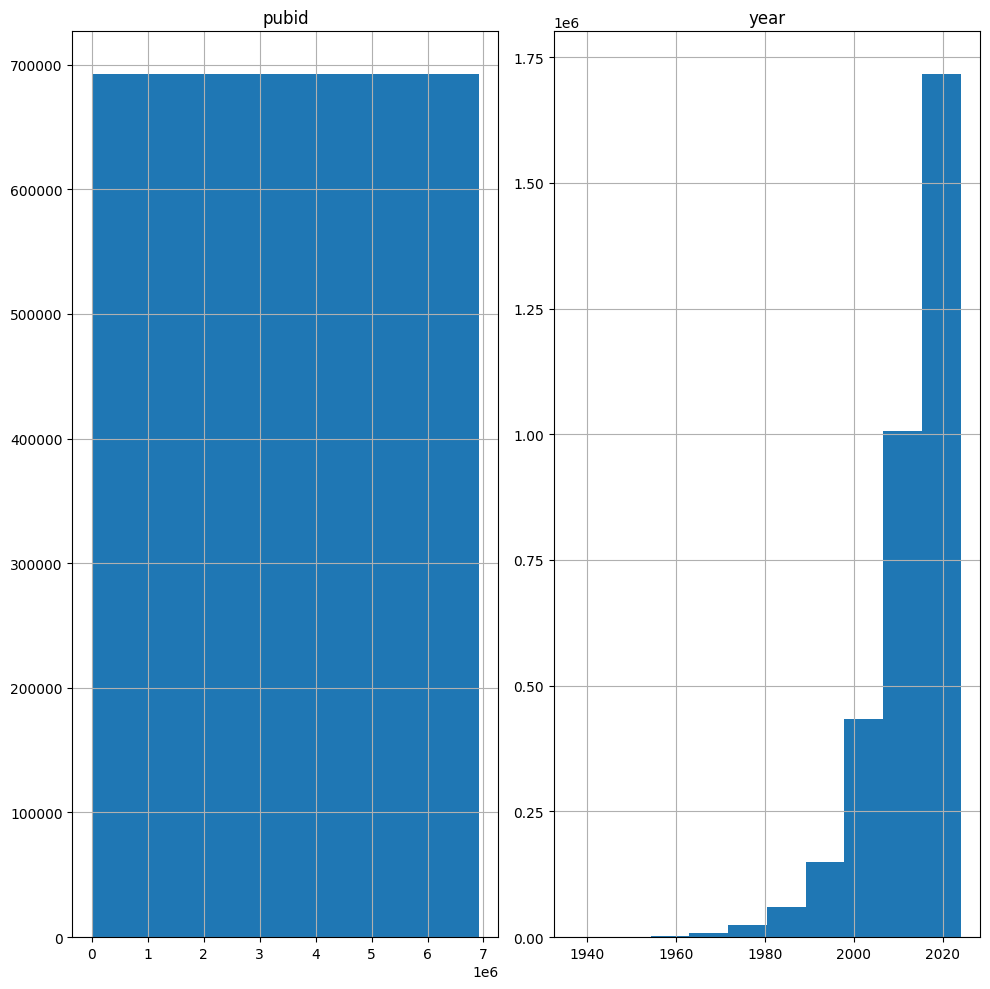

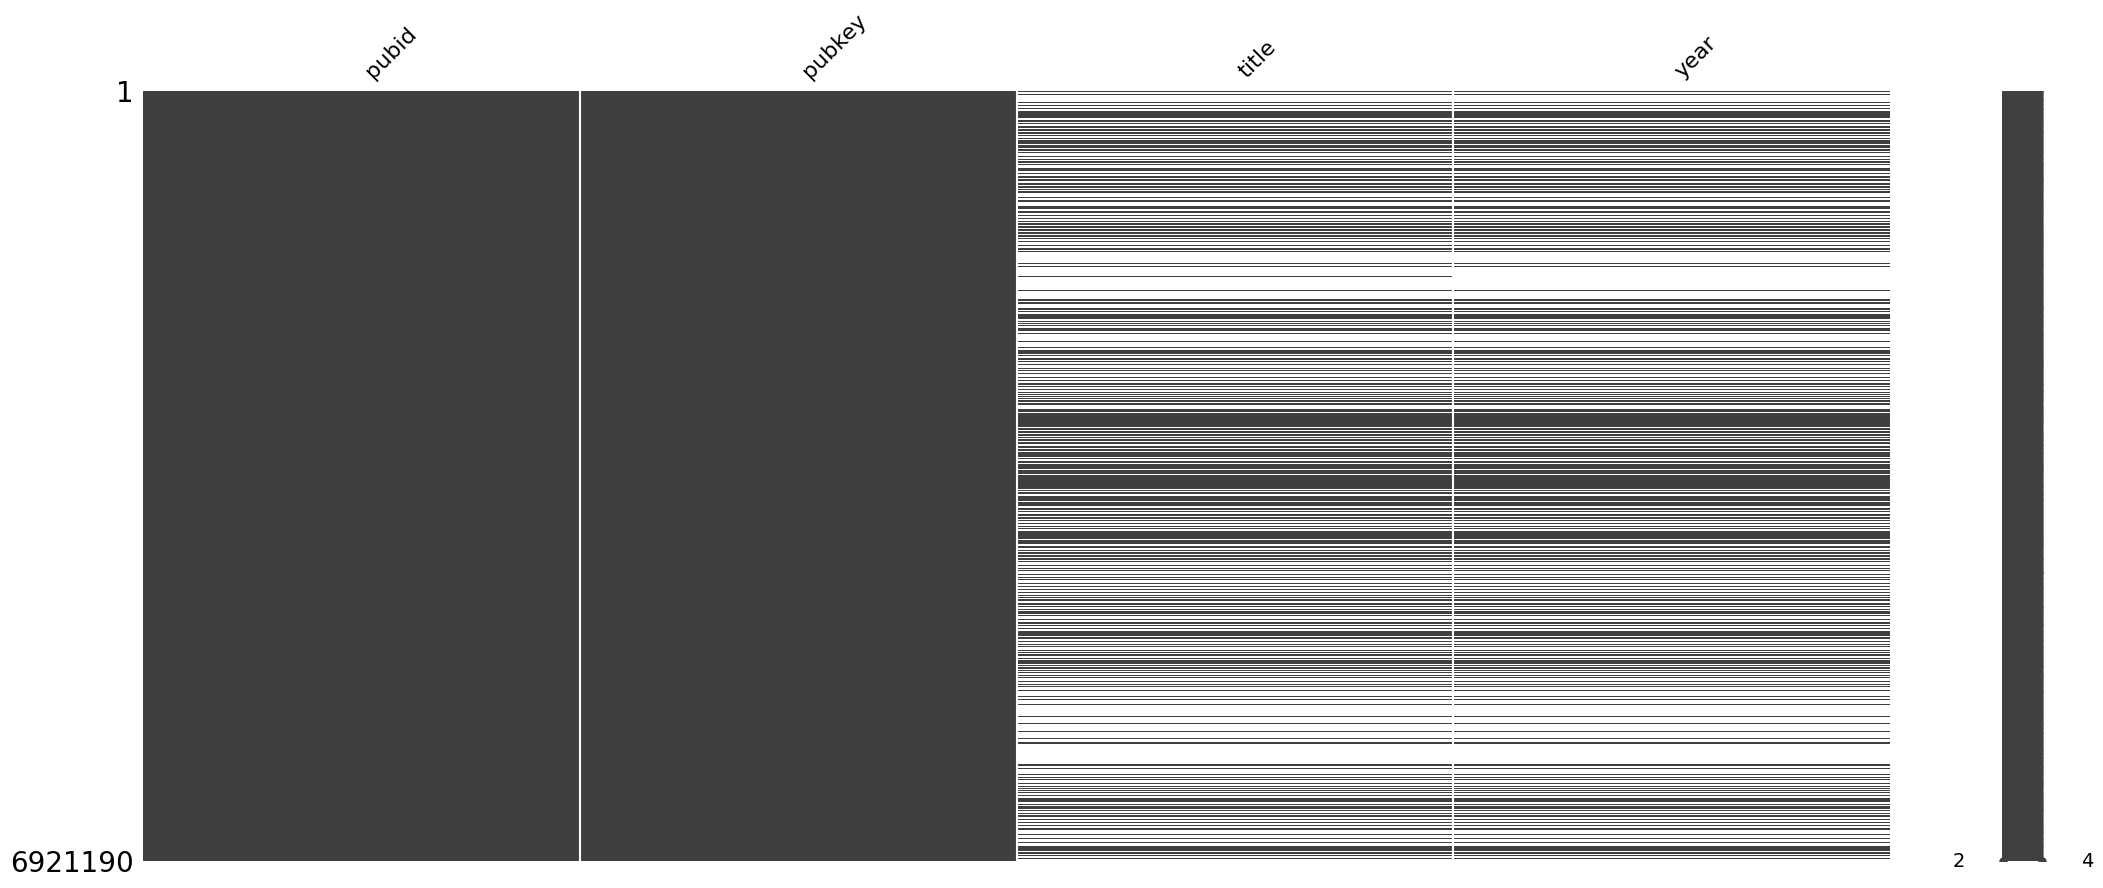

In [4]:
def load_and_analyze_csv(file_path):
    # Load the CSV into a DataFrame
    df = pd.read_csv(file_path)
    
    # Display the first few rows of the DataFrame
    print("First few rows of the DataFrame:")
    print(df.head())
    
    # Get the DataFrame shape (rows, columns)
    print("\nDataFrame shape:", df.shape)
    
    # Display data types of each column
    print("\nData types of each column:")
    print(df.dtypes)
    
    # Calculate null percentage for each column
    null_percentage = df.isnull().sum() * 100 / len(df)
    print("\nNull value percentage per column:")
    print(null_percentage)
    
    # Summary statistics for numerical columns
    print("\nSummary statistics for numerical columns:")
    print(df.describe())
    
    # Display unique value counts for each column that is categorical
    for col in df.select_dtypes(include=['object']).columns:
        print(f"\nUnique values in '{col}':", df[col].nunique())
        print(df[col].value_counts())

    # Histograms for all numerical columns
    df.hist(figsize=(10, 10))
    plt.tight_layout()
    plt.show()

    # Nullity matrix
    msno.matrix(df)
    plt.show()

# Path to the CSV file
file_path = '/data/home/lubarsky/phd/s2ag-corpus/base_dir/csvs_dataset/dblp_publication.csv'

# Call the function with the path to the CSV file
load_and_analyze_csv(file_path)


## dblp_publication

In [14]:
import pandas as pd

# Define the file path
file_path = '/data/home/lubarsky/phd/s2ag-corpus/base_dir/csvs_dataset/dblp_publication.csv'

# Load the DataFrame from CSV
dblp_publication_df = pd.read_csv(file_path)

# Show original dtypes
print("Original dtypes:")
print(dblp_publication_df.dtypes)

# Convert 'pubkey' and 'title' from object to string
dblp_publication_df['pubkey'] = dblp_publication_df['pubkey'].astype('string')
dblp_publication_df['title'] = dblp_publication_df['title'].astype('string')

# Convert 'year' from object to datetime
# Assuming the format in the 'year' column is consistent as 'YYYY-MM-DD' or just 'YYYY'
dblp_publication_df['year'] = pd.to_datetime(dblp_publication_df['year'], errors='coerce', format='%Y-%m-%d')

# Validate the changes
print("\nUpdated dtypes:")
print(dblp_publication_df.dtypes)

# Show the first few rows to verify
print("\nUpdated DataFrame:")
print(dblp_publication_df.head())

# Write the modified DataFrame back to CSV
# dblp_publication_df.to_csv(file_path, index=False)

Original dtypes:
pubid      int64
pubkey    object
title     object
year      object
dtype: object

Updated dtypes:
pubid              int64
pubkey    string[python]
title     string[python]
year      datetime64[ns]
dtype: object

Updated DataFrame:
     pubid                          pubkey title year
0  2987747        journals/ijista/PengXC05  <NA>  NaT
1  2987748           journals/ile/LinCHW16  <NA>  NaT
2  2987749  journals/ile/MousavinasabZKR21  <NA>  NaT
3  2987750               journals/ile/X17c  <NA>  NaT
4  2987751       journals/ile/MilkovaPAJ23  <NA>  NaT


In [19]:
# Calculate minimum year
min_time = dblp_publication_df['year'].min()
print("Minimum year:", min_time)

# Calculate maximum year
max_time = dblp_publication_df['year'].max()
print("Maximum year:", max_time)

# Calculate median year
median_time = dblp_publication_df['year'].median()
print("Median year:", median_time)

# Calculate the 80th percentile
p80_time = dblp_publication_df['year'].quantile(0.8)
print("80th percentile:", p80_time)

# Calculate the 90th percentile
p90_time = dblp_publication_df['year'].quantile(0.9)
print("90th percentile:", p90_time)

Minimum year: 1937-01-01 00:00:00
Maximum year: 2024-01-01 00:00:00
Median year: 2016-01-01 00:00:00
80th percentile: 2021-01-01 00:00:00
90th percentile: 2022-01-01 00:00:00


## ssd_papers

In [22]:
import pandas as pd

# Define the file path
file_path = '/data/home/lubarsky/phd/s2ag-corpus/base_dir/csvs_dataset/ssd_papers.csv'

# Load the DataFrame from CSV
ssd_papers_df = pd.read_csv(file_path)

# Show original dtypes
print("Original dtypes:")
print(ssd_papers_df.dtypes)

# Remove duplicated rows based on dblp_external_id, keeping the one with the lowest corpusid
ssd_papers_df = ssd_papers_df.sort_values('corpusid').drop_duplicates('dblp_external_id', keep='first')

# Verify the result
print("Number of rows after removing duplicates:", len(ssd_papers_df))

# Optionally, save the cleaned DataFrame back to a CSV file
ssd_papers_df.to_csv('/data/home/lubarsky/phd/s2ag-corpus/base_dir/csvs_dataset/ssd_papers.csv', index=False)

Original dtypes:
dblp_external_id             object
url                          object
year                        float64
title                        object
venue                        object
authors                      object
journal_name                 object
journal_pages                object
journal_volume               object
corpusid                      int64
externalids                  object
isopenaccess                   bool
citationcount                 int64
referencecount                int64
publicationdate              object
fields_of_study              object
publication_types            object
publicationvenueid           object
influentialcitationcount      int64
dtype: object
Number of rows after removing duplicates: 6720376


In [23]:
import pandas as pd

# Define the file path
file_path = '/data/home/lubarsky/phd/s2ag-corpus/base_dir/csvs_dataset/ssd_papers.csv'

# Load the DataFrame from CSV
ssd_papers_df = pd.read_csv(file_path)

# Show original dtypes
print("Original dtypes:")
print(ssd_papers_df.dtypes)

Original dtypes:
dblp_external_id             object
url                          object
year                        float64
title                        object
venue                        object
authors                      object
journal_name                 object
journal_pages                object
journal_volume               object
corpusid                      int64
externalids                  object
isopenaccess                   bool
citationcount                 int64
referencecount                int64
publicationdate              object
fields_of_study              object
publication_types            object
publicationvenueid           object
influentialcitationcount      int64
dtype: object
